In [77]:
import pandas as pd
import numpy as np
import re, string
from collections import Counter

In [78]:
# Load the training dataset
df = pd.read_csv("Train.csv")

print("Initial shape:", df.shape)
df.head()

Initial shape: (10001, 4)


,tweet_id,safe_text,label,agreement
0,CL1KWCMY,Me &amp; The Big Homie meanboy3000 #MEANBOY #M...,0.0,1.0
1,E3303EME,I'm 100% thinking of devoting my career to pro...,1.0,1.0
2,M4IVFSMS,"#whatcausesautism VACCINES, DO NOT VACCINATE Y...",-1.0,1.0
3,1DR6ROZ4,I mean if they immunize my kid with something ...,-1.0,1.0
4,J77ENIIE,Thanks to <user> Catch me performing at La Nui...,0.0,1.0


In [79]:
print("Unique label values:")
print(df["label"].unique())

print("\nLabel counts:")
print(df["label"].value_counts())

Unique label values:
[ 0.          1.         -1.                 nan  0.66666667]

Label counts:
label
 0.000000    4908
 1.000000    4053
-1.000000    1038
 0.666667       1
Name: count, dtype: int64


In [80]:
# Keep only valid labels
df = df[df["label"].isin([-1.0, 0.0, 1.0])]

print("Shape after removing invalid labels:", df.shape)
print("\nUpdated label distribution:")
print(df["label"].value_counts())

Shape after removing invalid labels: (9999, 4)

Updated label distribution:
label
 0.0    4908
 1.0    4053
-1.0    1038
Name: count, dtype: int64


In [81]:
label_map = {-1.0: "negative", 0.0: "neutral", 1.0: "positive"}
df["label_name"] = df["label"].map(label_map)

print(df["label_name"].value_counts())

label_name
neutral     4908
positive    4053
negative    1038
Name: count, dtype: int64


In [82]:
df["safe_text"] = df["safe_text"].fillna("").astype(str)

empty_mask = df["safe_text"].str.strip().eq("")
print("Empty/blank text rows:", empty_mask.sum())

# Optional: remove blank text (recommended)
df = df[~empty_mask].copy()
print("Shape after removing blank texts:", df.shape)

Empty/blank text rows: 0
Shape after removing blank texts: (9999, 5)


In [83]:
dist_counts = df["label_name"].value_counts()
dist_pct = df["label_name"].value_counts(normalize=True) * 100

summary_sentiment = pd.DataFrame({
    "count": dist_counts,
    "percent": dist_pct.round(2)
})

summary_sentiment

,count,percent
label_name,,
neutral,4908,49.08
positive,4053,40.53
negative,1038,10.38


In [84]:
df["char_len"] = df["safe_text"].apply(len)
df["word_len"] = df["safe_text"].apply(lambda x: len(x.split()))

df[["char_len", "word_len"]].describe()

,char_len,word_len
count,9999.000000,9999.000000
mean,99.921092,16.267427
std,29.868721,5.344624
min,3.000000,1.000000
25%,80.000000,13.000000
50%,107.000000,17.000000
75%,122.000000,20.000000
max,153.000000,33.000000


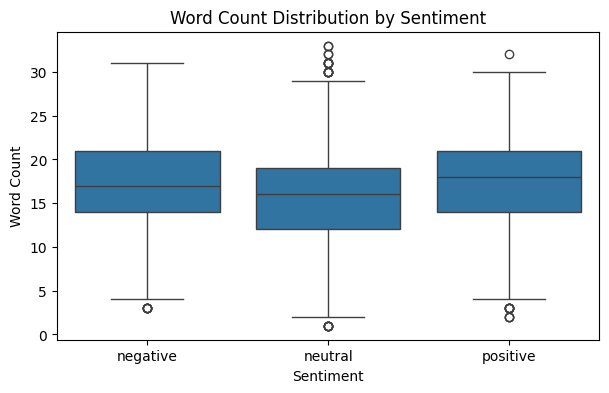

In [85]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,4))
sns.boxplot(data=df, x="label_name", y="word_len", order=["negative","neutral","positive"])
plt.title("Word Count Distribution by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Word Count")
plt.show()

In [86]:
length_by_class = df.groupby("label_name")[["char_len", "word_len"]].agg(["mean", "median", "min", "max"]).round(2)
length_by_class

char_len                 word_len               
               mean median min  max     mean median min max
label_name                                                 
negative     103.61  109.0  18  153    16.92   17.0   3  31
neutral       95.64  104.0   3  148    15.54   16.0   1  33
positive     104.16  111.0  17  152    16.98   18.0   2  32

In [87]:
# ---- Agreement Analysis ----

print("Agreement statistics (overall):")
display(df["agreement"].describe())

print("\nAverage agreement per sentiment:")
agreement_by_class = df.groupby("label_name")["agreement"].mean().round(3)
display(agreement_by_class)

Agreement statistics (overall):


,agreement
count,9999.000000
mean,0.854252
std,0.180707
min,0.333333
25%,0.666667
50%,1.000000
75%,1.000000
max,1.000000



Average agreement per sentiment:


,agreement
label_name,
negative,0.713
neutral,0.881
positive,0.858


In [88]:
# ---- Correlation Analysis ----

corr_matrix = df[["word_len", "char_len", "agreement"]].corr()

print("Correlation matrix:")
display(corr_matrix)

Correlation matrix:


,word_len,char_len,agreement
word_len,1.000000,0.904822,-0.047079
char_len,0.904822,1.000000,-0.061393
agreement,-0.047079,-0.061393,1.000000


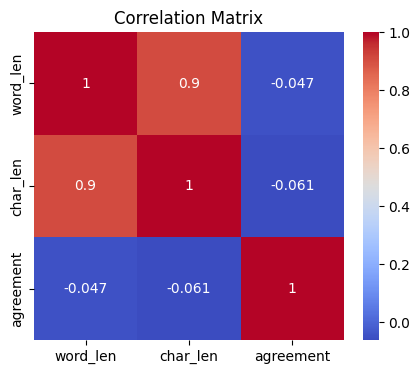

In [89]:
plt.figure(figsize=(5,4))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [90]:
# ---- Outlier Detection (Word Length) ----

q1 = df["word_len"].quantile(0.25)
q3 = df["word_len"].quantile(0.75)
iqr = q3 - q1

upper_bound = q3 + 1.5 * iqr

outliers = df[df["word_len"] > upper_bound]

print("Number of length outliers:", len(outliers))
outliers[["safe_text", "word_len"]].head()
outliers_view = outliers.copy()
outliers_view["safe_text"] = "[REDACTED]"
outliers_view[["tweet_id", "label_name", "agreement", "word_len", "safe_text"]].head()

Number of length outliers: 13


,tweet_id,label_name,agreement,word_len,safe_text
1035,0I0SRZOU,neutral,1.000000,31,[REDACTED]
1651,RFYHY2BP,neutral,1.000000,31,[REDACTED]
1719,Y6QRNQSL,neutral,0.666667,32,[REDACTED]
1766,S0VPKXS3,neutral,0.666667,32,[REDACTED]
2648,4EG7BRJU,negative,0.666667,31,[REDACTED]


The texts were redacted due to the use of some offensive language, however you can remove the last three lines to check if you need to.

In [91]:
# ---- Low Agreement Tweets ----

low_agreement = df[df["agreement"] < df["agreement"].quantile(0.10)]

print("Tweets in lowest 10% agreement:", len(low_agreement))
low_agreement[["safe_text", "agreement"]].head()

Tweets in lowest 10% agreement: 239


,safe_text,agreement
35,"<user> <user> Other than that, his defense is ...",0.333333
138,Pro safety doesn't make me an anti-vaxer. It ...,0.333333
142,<user> <user> <user> <user> my understanding i...,0.333333
197,Parents Warned That Vaccinating Kids May Turn ...,0.333333
227,So apparently the nasal spray live culture flu...,0.333333


In [92]:
def normalize_for_counts(text: str) -> str:
    text = text.lower()
    text = re.sub(r"http\S+|www\.\S+", "", text)  # remove URLs
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["text_norm"] = df["safe_text"].apply(normalize_for_counts)
df[["safe_text", "text_norm"]].head(3)

,safe_text,text_norm
0,Me &amp; The Big Homie meanboy3000 #MEANBOY #M...,me amp the big homie meanboy3000 meanboy mb mb...
1,I'm 100% thinking of devoting my career to pro...,im 100 thinking of devoting my career to provi...
2,"#whatcausesautism VACCINES, DO NOT VACCINATE Y...",whatcausesautism vaccines do not vaccinate you...


In [93]:
!pip -q install seaborn wordcloud

In [94]:
from wordcloud import WordCloud, STOPWORDS
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

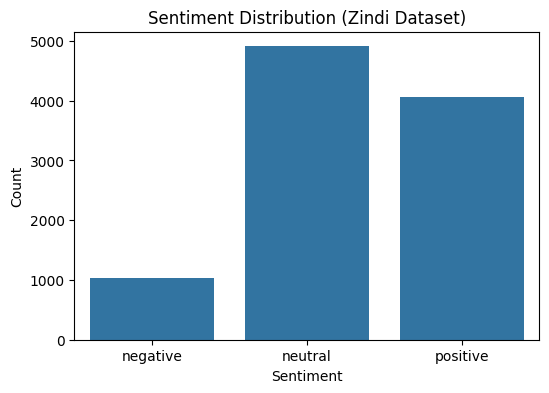

In [95]:
plt.figure(figsize=(6,4))
sns.countplot(x="label_name", data=df, order=["negative","neutral","positive"])
plt.title("Sentiment Distribution (Zindi Dataset)")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

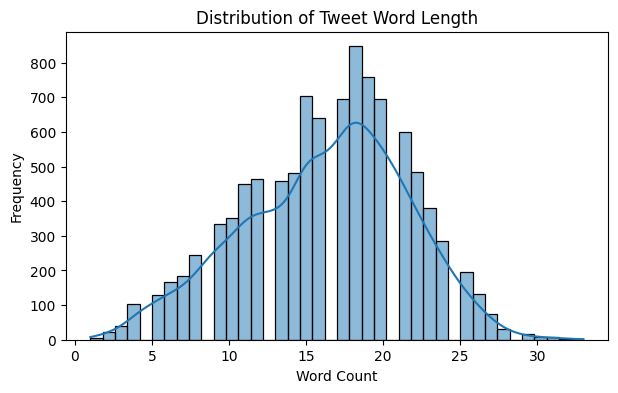

In [96]:
plt.figure(figsize=(7,4))
sns.histplot(df["word_len"], bins=40, kde=True)
plt.title("Distribution of Tweet Word Length")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

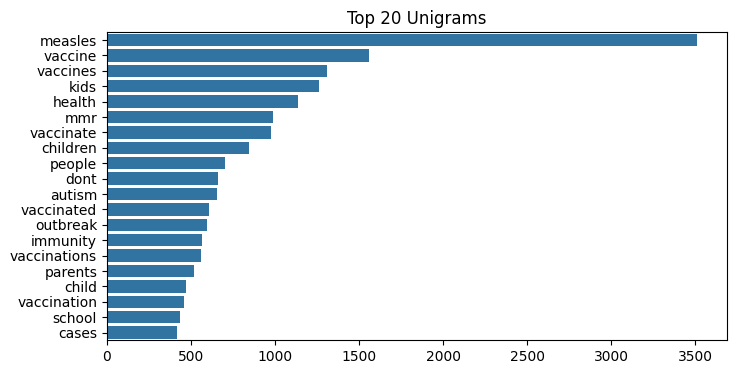

In [97]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

custom_stopwords = list(ENGLISH_STOP_WORDS) + ["user", "url", "amp"] # Removed tweet placeholders ("user", "url") and HTML artifact "amp" since they do not provide meaningful infor for text analysis
vectorizer_uni = CountVectorizer(max_features=20, stop_words=custom_stopwords)

X_uni = vectorizer_uni.fit_transform(df["text_norm"])

word_counts = X_uni.sum(axis=0).A1
words = vectorizer_uni.get_feature_names_out()

top_uni = sorted(zip(words, word_counts), key=lambda x: x[1], reverse=True)

words_plot = [w for w, c in top_uni]
counts_plot = [c for w, c in top_uni]

plt.figure(figsize=(8,4))
sns.barplot(x=counts_plot, y=words_plot)
plt.title("Top 20 Unigrams")
plt.show()

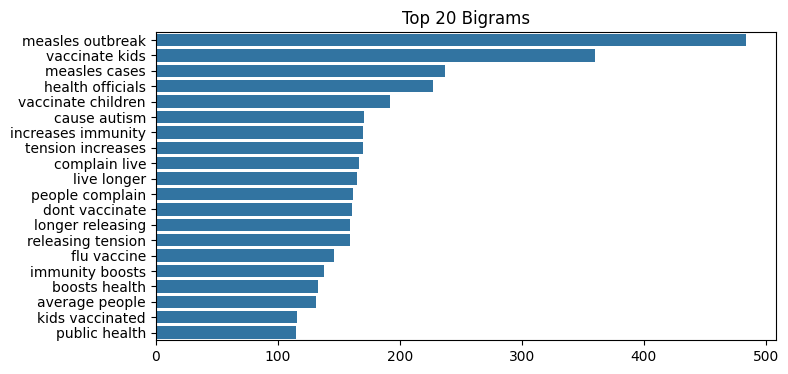

In [98]:
vectorizer_bi = CountVectorizer(ngram_range=(2,2), max_features=20, stop_words=custom_stopwords )
X_bi = vectorizer_bi.fit_transform(df["text_norm"])

bigram_counts = X_bi.sum(axis=0).A1
bigrams = vectorizer_bi.get_feature_names_out()

top_bi = sorted(zip(bigrams, bigram_counts), key=lambda x: x[1], reverse=True)

bigrams_plot = [w for w, c in top_bi]
counts_plot = [c for w, c in top_bi]

plt.figure(figsize=(8,4))
sns.barplot(x=counts_plot, y=bigrams_plot)
plt.title("Top 20 Bigrams")
plt.show()

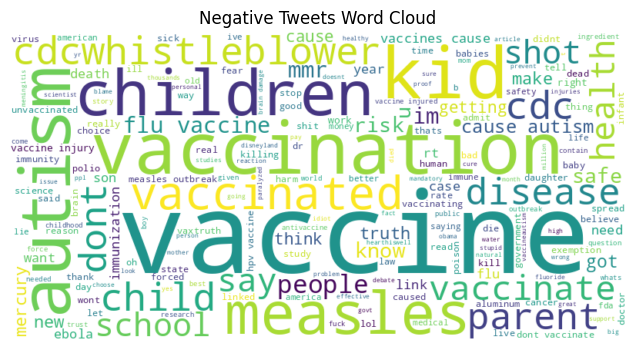

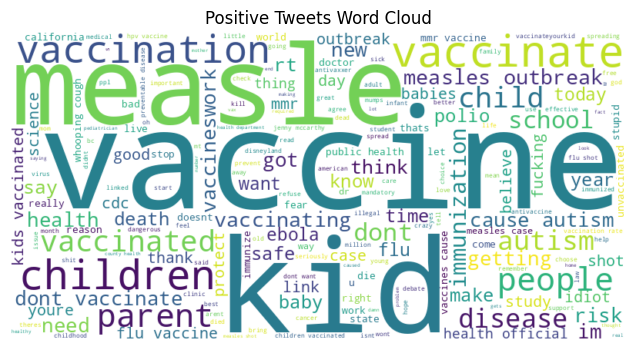

In [99]:
def plot_wordcloud(text, title):
    wc_stopwords = set(STOPWORDS)
    wc_stopwords.update(custom_stopwords)

    wc = WordCloud(
        width=800,
        height=400,
        background_color="white",
        stopwords=wc_stopwords
    ).generate(text)

    plt.figure(figsize=(10,4))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(title)
    plt.show()

plot_wordcloud(" ".join(df[df["label_name"]=="negative"]["text_norm"]), "Negative Tweets Word Cloud")
plot_wordcloud(" ".join(df[df["label_name"]=="positive"]["text_norm"]), "Positive Tweets Word Cloud")

In [100]:
vectorizer_topic = CountVectorizer(max_df=0.95, min_df=5, stop_words=custom_stopwords)
X_topic = vectorizer_topic.fit_transform(df["text_norm"])

lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(X_topic)

def display_topics(model, feature_names, no_top_words=10):
    for topic_idx, topic in enumerate(model.components_):
        print(f"\nTopic {topic_idx+1}:")
        print(" ".join([feature_names[i]
                        for i in topic.argsort()[:-no_top_words - 1:-1]]))

display_topics(lda, vectorizer_topic.get_feature_names_out())


Topic 1:
vaccines autism cause mmr vaccine vaccinations immunity health diseases immunizations

Topic 2:
vaccine health flu people immunity live measles longer complain increases

Topic 3:
vaccine school mmr vaccination disease children vaccines immunity today got

Topic 4:
measles outbreak health cases officials disneyland county case confirmed california

Topic 5:
kids vaccinate children dont vaccinated mmr parents people im child


In [101]:
from collections import Counter

# Use the same stopword list you used before
stop_set = set(custom_stopwords)

tokens_all = " ".join(df["text_norm"].astype(str)).split()

# Remove stopwords + placeholders (user/url/amp) before counting
tokens_all = [t for t in tokens_all if t not in stop_set]

top_overall = Counter(tokens_all).most_common(20)

pd.DataFrame(top_overall, columns=["word", "count"])

,word,count
0,measles,3466
1,vaccine,1548
2,vaccines,1304
3,kids,1253
4,health,1005
5,vaccinate,974
6,mmr,958
7,children,835
8,people,696
9,dont,658


In [102]:
top_words_by_class = {}

for cls in ["negative", "neutral", "positive"]:

    cls_tokens = [t for t in " ".join(df.loc[df["label_name"] == cls, "text_norm"]).split()
                  if t not in custom_stopwords]

    top_words_by_class[cls] = Counter(cls_tokens).most_common(20)

for cls, top in top_words_by_class.items():
    print("\n===", cls.upper(), "===")
    for w, c in top[:15]:
        print(w, c)


=== NEGATIVE ===
vaccines 319
vaccine 295
autism 175
kids 112
measles 109
children 101
vaccinations 84
dont 80
vaccinate 75
vaccinated 72
“user 68
cause 66
flu 64
cdcwhistleblower 63
cdc 61

=== NEUTRAL ===
measles 2414
mmr 765
health 568
vaccine 566
immunity 505
outbreak 377
“user 317
cases 317
people 313
vaccines 260
live 229
disneyland 220
kids 218
new 212
officials 207

=== POSITIVE ===
measles 943
kids 923
vaccinate 789
vaccines 725
vaccine 687
children 564
dont 431
vaccinated 418
autism 399
health 382
parents 346
people 340
vaccinations 333
child 299
vaccination 243


TF-IDF was applied to identify the most informative terms in the dataset. Unlike raw frequency counts, TF-IDF reduces the influence of very common words and highlights terms that are particularly important within the corpus or within a specific sentiment class.

In [103]:
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from scipy.sparse import save_npz
import joblib, os


OUT_DIR = "zindi_eda_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

# Add dataset-specific stopwords to the standard English ones
custom_stopwords = set(["user", "url", "amp", "rt"])
all_stopwords = list(ENGLISH_STOP_WORDS) + list(custom_stopwords)

vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    stop_words=all_stopwords  # IMPORTANT
)

X = vectorizer.fit_transform(df["text_norm"].fillna("").astype(str))
print("TF-IDF shape:", X.shape)

save_npz(os.path.join(OUT_DIR, "zindi_tfidf_matrix.npz"), X)
joblib.dump(vectorizer, os.path.join(OUT_DIR, "zindi_tfidf_vectorizer.joblib"))

pd.DataFrame({"feature": vectorizer.get_feature_names_out()}).to_csv(
    os.path.join(OUT_DIR, "zindi_tfidf_features.csv"), index=False
)

# Optional row mapping (recommended if you want traceability later)
if "tweet_id" in df.columns:
    df[["tweet_id"]].reset_index(drop=True).to_csv(
        os.path.join(OUT_DIR, "zindi_tfidf_row_mapping.csv"), index=False
    )

print("Saved TF-IDF artifacts in:", OUT_DIR)

TF-IDF shape: (9999, 5000)
Saved TF-IDF artifacts in: zindi_eda_outputs


In [104]:
feature_names = vectorizer.get_feature_names_out()
scores = np.asarray(X.sum(axis=0)).ravel()

top_idx = scores.argsort()[::-1][:20]
top_tfidf = pd.DataFrame({
    "term": feature_names[top_idx],
    "total_tfidf": scores[top_idx]
}).reset_index(drop=True)

top_tfidf

,term,total_tfidf
0,measles,467.738913
1,mmr,250.529501
2,vaccine,237.471784
3,kids,221.830837
4,vaccines,218.598296
5,vaccinate,197.661443
6,health,172.104701
7,children,165.464431
8,autism,135.206725
9,vaccinated,133.845427


In [105]:
feature_names = vectorizer.get_feature_names_out()

def top_tfidf_terms_for_mask(mask, X_full, k=15):
    X_sub = X_full[mask]  # mask is True/False for each row
    s = np.asarray(X_sub.sum(axis=0)).ravel()
    top_idx = s.argsort()[::-1][:k]
    return pd.DataFrame({
        "term": feature_names[top_idx],
        "total_tfidf": s[top_idx]
    })

mask_neg = (df["label_name"] == "negative").to_numpy()
mask_neu = (df["label_name"] == "neutral").to_numpy()
mask_pos = (df["label_name"] == "positive").to_numpy()

top_tfidf_negative = top_tfidf_terms_for_mask(mask_neg, X, k=15)
top_tfidf_neutral  = top_tfidf_terms_for_mask(mask_neu, X, k=15)
top_tfidf_positive = top_tfidf_terms_for_mask(mask_pos, X, k=15)

print("NEGATIVE top TF-IDF terms:")
display(top_tfidf_negative)

print("NEUTRAL top TF-IDF terms:")
display(top_tfidf_neutral)

print("POSITIVE top TF-IDF terms:")
display(top_tfidf_positive)

NEGATIVE top TF-IDF terms:


,term,total_tfidf
0,vaccines,55.250503
1,vaccine,47.936326
2,autism,38.752989
3,kids,21.069908
4,children,20.700203
5,cdcwhistleblower,20.040830
6,vaccinations,19.552110
7,cause,17.294004
8,dont,16.563160
9,vaccinated,16.406591


NEUTRAL top TF-IDF terms:


,term,total_tfidf
0,measles,347.825561
1,mmr,216.285373
2,health,98.893304
3,immunity,95.422945
4,vaccine,87.210828
5,outbreak,80.944438
6,measles outbreak,72.886268
7,cases,64.343456
8,disneyland,59.214973
9,people,54.334147


POSITIVE top TF-IDF terms:


,term,total_tfidf
0,kids,163.046072
1,vaccinate,159.587703
2,vaccines,117.549743
3,children,111.927376
4,measles,107.119253
5,vaccine,102.324629
6,vaccinated,92.404666
7,dont,84.280311
8,vaccinate kids,82.035677
9,autism,78.306276


In [106]:
if "summary_sentiment" in globals():
    summary_sentiment.to_csv(os.path.join(OUT_DIR, "summary_sentiment_distribution.csv"))

if "length_by_class" in globals():
    length_by_class.to_csv(os.path.join(OUT_DIR, "summary_length_by_class.csv"))

print("Saved comparison summaries into:", OUT_DIR)

Saved comparison summaries into: zindi_eda_outputs
